In [1]:
# import the stuff you need. Pytorch is already installed on Google colab
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
from huggingface_hub import hf_hub_download

import sys
sys.path.append('../')
from helper import *

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants
DATA_PATH = "dataset"
BATCH_SIZE = 64

In [3]:
# # Download dataset
# hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=".")
# hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=".")

In [4]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [5]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

In [6]:
print("Spectra:", spectra.shape)
print("Labels:", labels.shape)

Spectra: (8914, 16384)
Labels: (8914, 3)


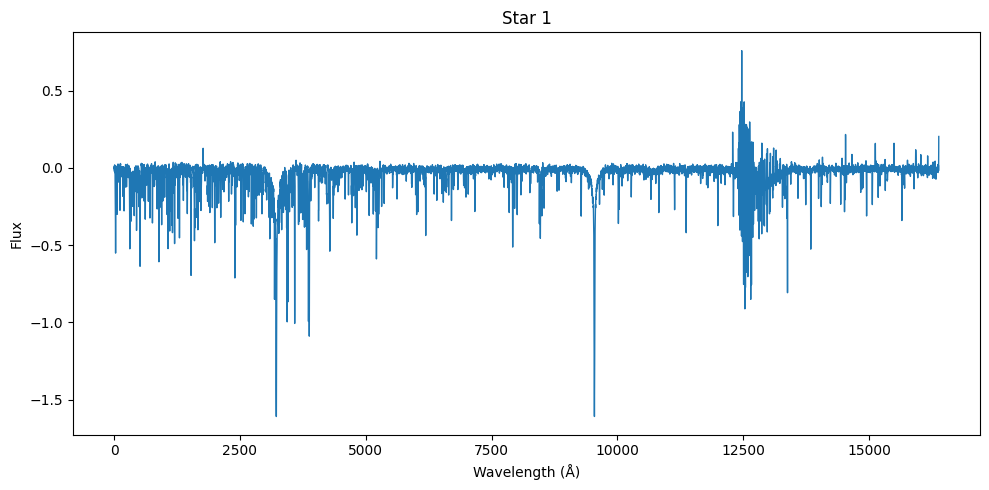

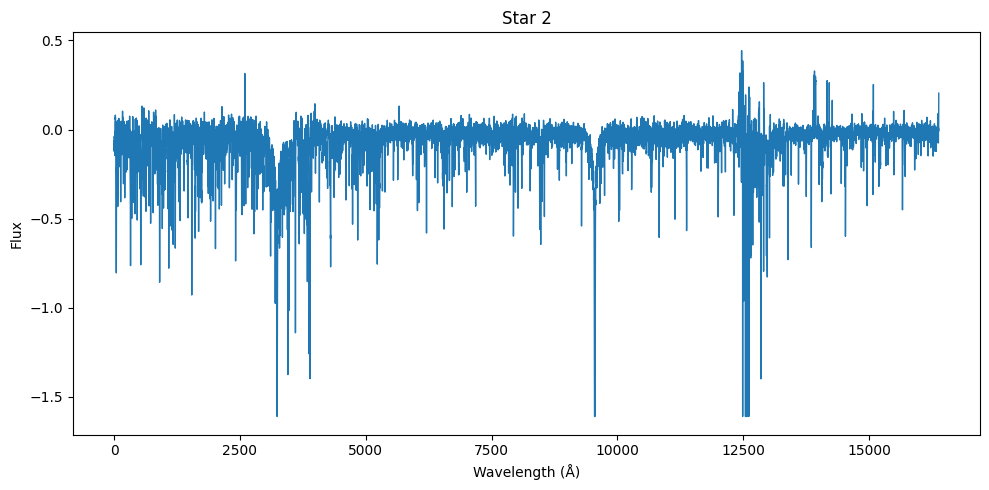

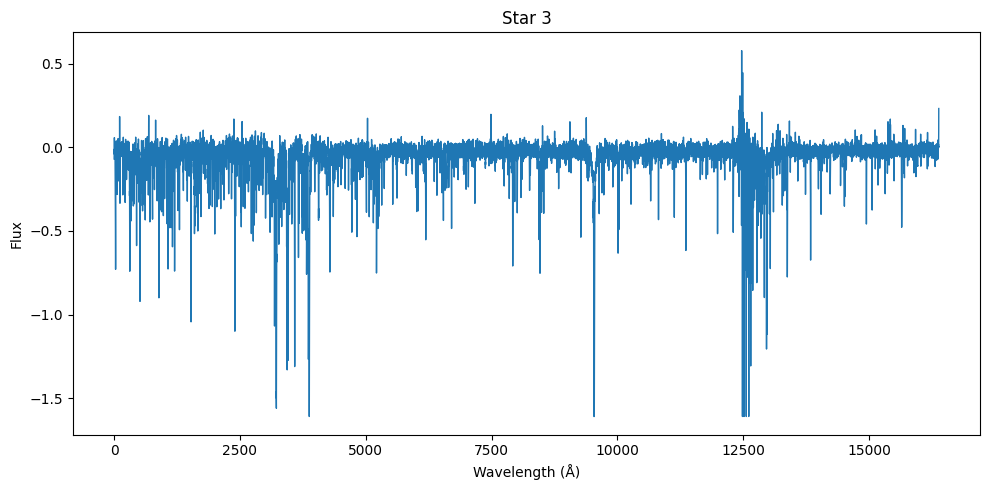

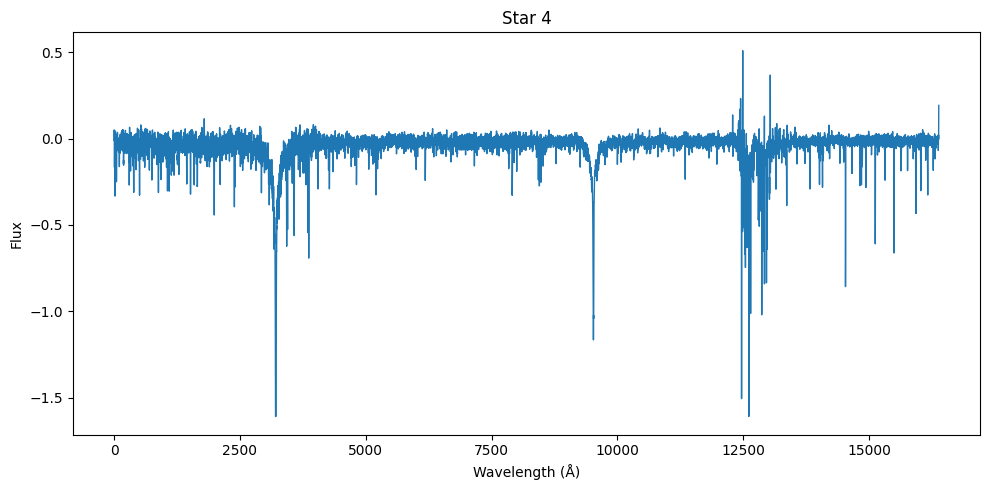

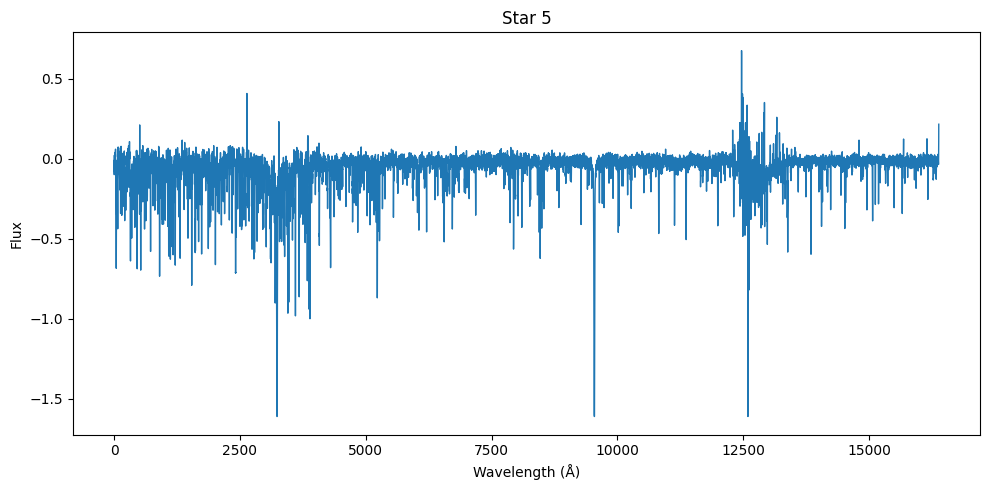

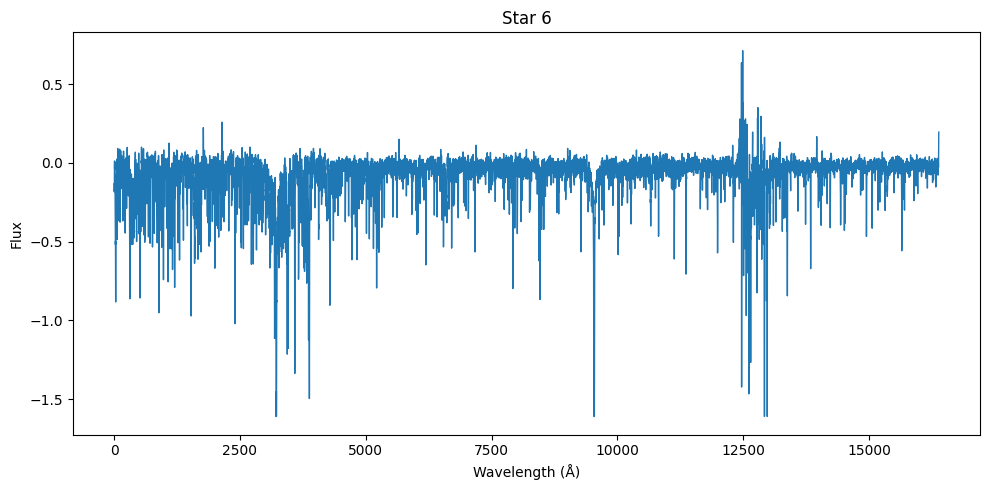

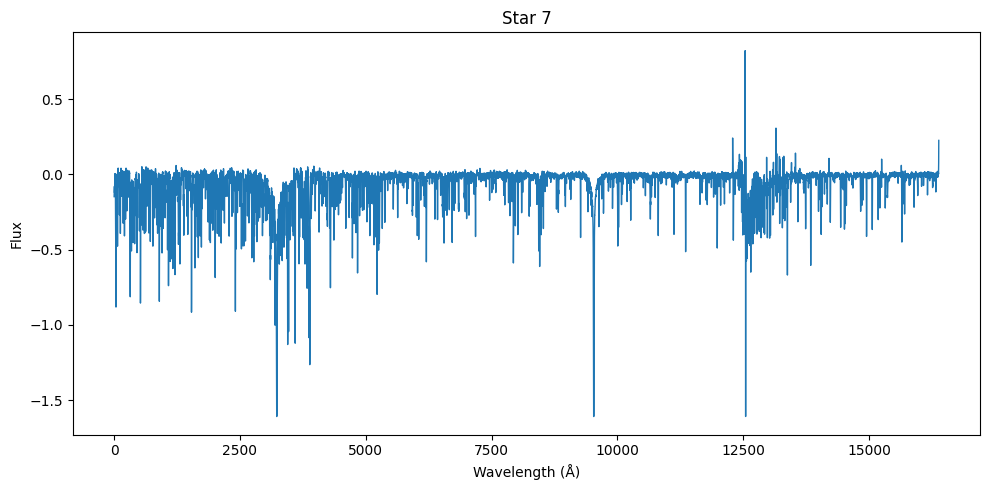

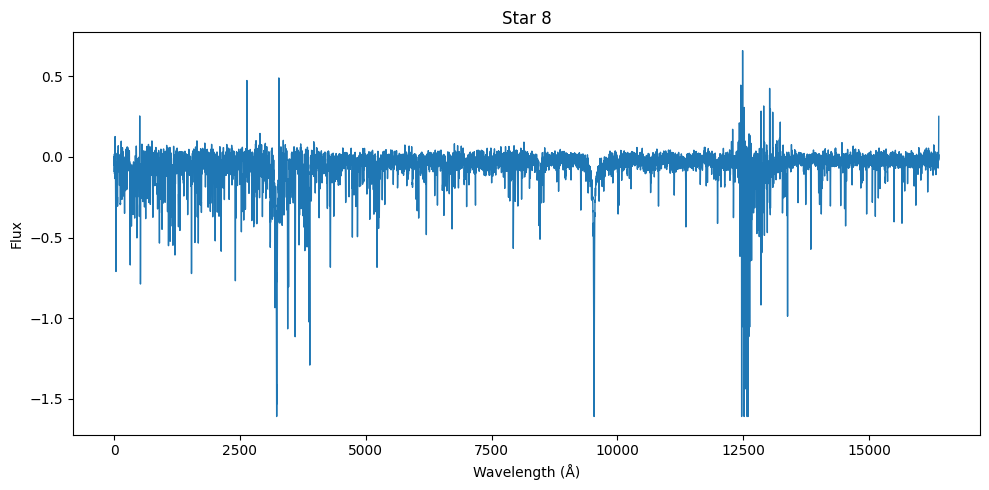

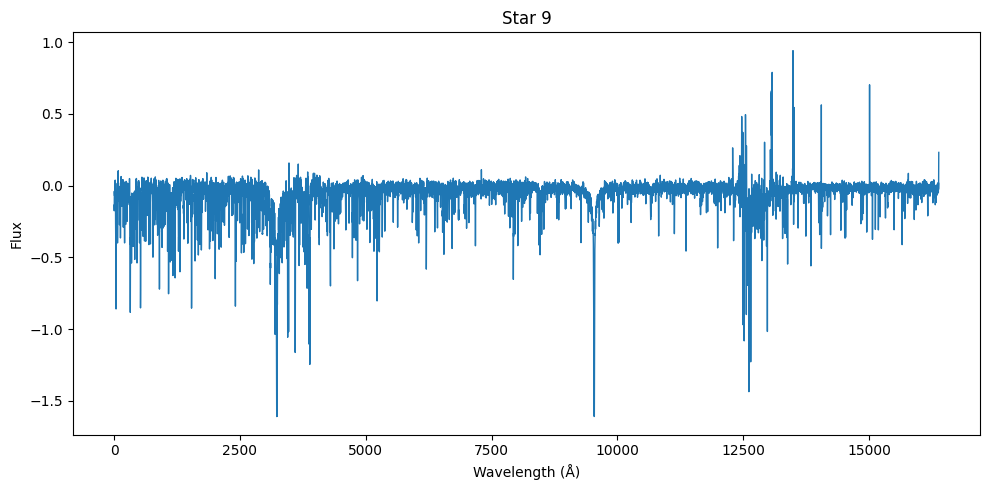

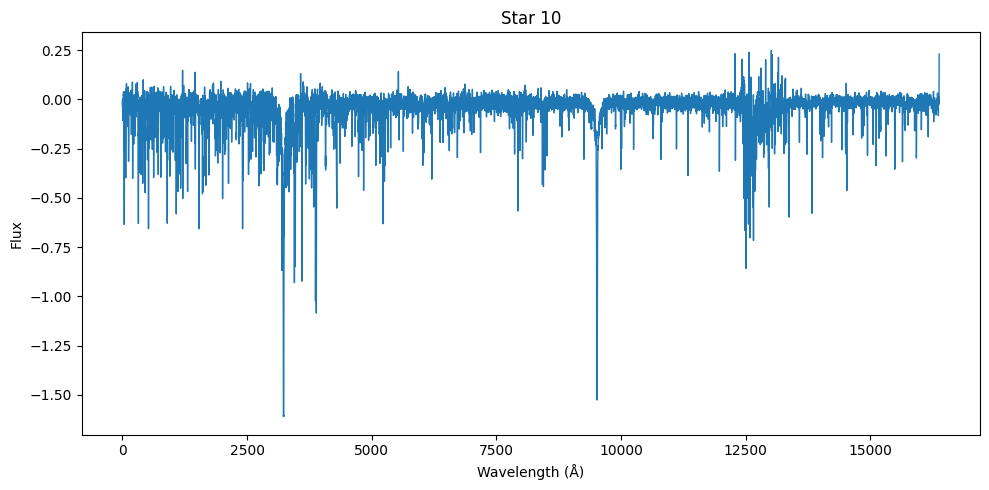

In [22]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i+1}")
  plt.xlabel("Wavelength (Å)")
  plt.ylabel("Flux")
  plt.tight_layout()

In [8]:
# Splitting into train, val and test datasets

X_train, X_val, X_test, y_train, y_val, y_test = split_data(spectra, labels)

print(f"Shapes of train, test and val X : {X_train.shape}, {X_val.shape}, {X_test.shape}")
print(f"Shapes of train, test and val y : {y_train.shape}, {y_val.shape}, {y_test.shape}")

Shapes of train, test and val X : (6239, 16384), (1337, 16384), (1338, 16384)
Shapes of train, test and val y : (6239, 3), (1337, 3), (1338, 3)


In [9]:
y_train, y_val, y_test, mean, std = normalize_labels(y_train, y_val, y_test)

In [10]:
train_loader, val_loader, test_loader = load_dataset(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=BATCH_SIZE)

In [11]:
class SpectraCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 6)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [12]:
# NLL Loss function

def nll_loss(predictions, targets):
    n_labels = targets.shape[1]

    assert predictions.shape[1] == 2 * n_labels, \
        f"Expected {2*n_labels}, got {predictions.shape[1]}"
    # Split outputs
    mean = predictions[:, :n_labels]
    log_std = predictions[:, n_labels:]

    # Convert to std
    std = torch.exp(log_std)

    # NLL loss
    loss = 0.5 * ((targets - mean) / std) ** 2 + log_std

    return torch.mean(loss)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = SpectraCNN().to(device)
print(summary(model, input_size=(1, 16384)))

cuda


Layer (type:depth-idx)                   Output Shape              Param #
SpectraCNN                               [1, 6]                    --
├─Sequential: 1-1                        [1, 64, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 16384]            128
│    └─ReLU: 2-2                         [1, 16, 16384]            --
│    └─MaxPool1d: 2-3                    [1, 16, 8192]             --
│    └─Conv1d: 2-4                       [1, 32, 8192]             3,616
│    └─ReLU: 2-5                         [1, 32, 8192]             --
│    └─MaxPool1d: 2-6                    [1, 32, 4096]             --
│    └─Conv1d: 2-7                       [1, 64, 4096]             14,400
│    └─ReLU: 2-8                         [1, 64, 4096]             --
│    └─MaxPool1d: 2-9                    [1, 64, 2048]             --
├─AdaptiveAvgPool1d: 1-2                 [1, 64, 1]                --
├─Sequential: 1-3                        [1, 6]                    --
│    └─

In [14]:
config = {
    "epochs": 300,
    "lr": 1e-3,
    "optimizer": "adam",
    "loss_fn": nll_loss,
    "plateau": {"patience": 5, "factor": 0.5},
    "early_stop": {"patience": 10}
}

In [15]:
train_losses, val_losses = train_model(model, train_loader, val_loader, config, device)

Epoch 010 | Train: 0.2186 | Val: 0.2127 | LR: 0.001000
Epoch 020 | Train: -0.1576 | Val: -0.1647 | LR: 0.001000
Epoch 030 | Train: -0.3643 | Val: -0.3229 | LR: 0.001000
Epoch 040 | Train: -0.4658 | Val: -0.4279 | LR: 0.001000
Epoch 050 | Train: -0.5301 | Val: -0.4932 | LR: 0.001000
Epoch 060 | Train: -0.6087 | Val: -0.5646 | LR: 0.001000
Epoch 070 | Train: -0.7142 | Val: -0.7278 | LR: 0.001000
Epoch 080 | Train: -0.7876 | Val: -0.7462 | LR: 0.000500
Epoch 090 | Train: -0.8227 | Val: -0.8075 | LR: 0.000500
Epoch 100 | Train: -0.8683 | Val: -0.8269 | LR: 0.000250
Epoch 110 | Train: -0.8659 | Val: -0.8329 | LR: 0.000250
Epoch 120 | Train: -0.8880 | Val: -0.8502 | LR: 0.000250
Epoch 130 | Train: -0.9051 | Val: -0.8328 | LR: 0.000250
Epoch 140 | Train: -0.9249 | Val: -0.8853 | LR: 0.000125
Epoch 150 | Train: -0.9324 | Val: -0.8821 | LR: 0.000125
Epoch 160 | Train: -0.9382 | Val: -0.8904 | LR: 0.000125
Epoch 170 | Train: -0.9368 | Val: -0.8714 | LR: 0.000125
Epoch 180 | Train: -0.9486 | Val:

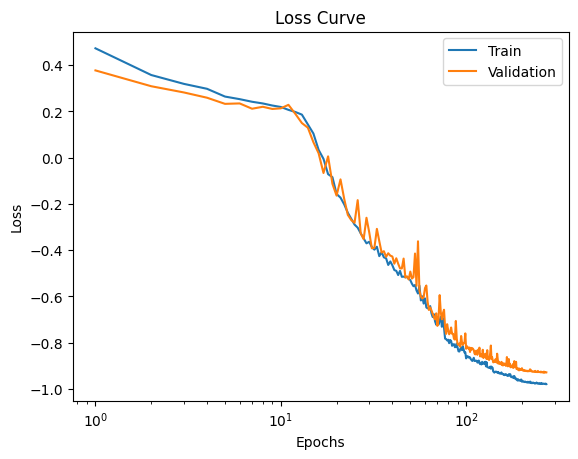

In [15]:
plot_loss(log_scale=True)

In [16]:
preds, y_true = evaluate_model(model, test_loader, device, config["loss_fn"], precomputed= True)

Loaded precomputed weights from best_model.pth
Average test loss: -0.9818


In [17]:
# Split mean and std
means = preds[:, :3]
log_std = preds[:, 3:]
stds = np.exp(log_std)

print(y_true.shape, means.shape)



(1338, 3) (1338, 3)


T_eff: Mean=-0.062, Std=1.051


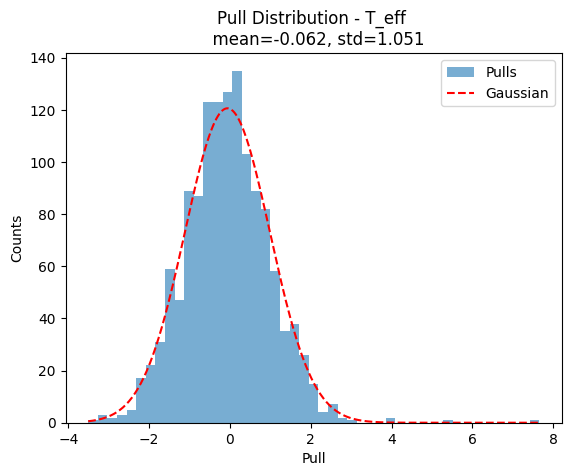

log_g: Mean=0.023, Std=1.006


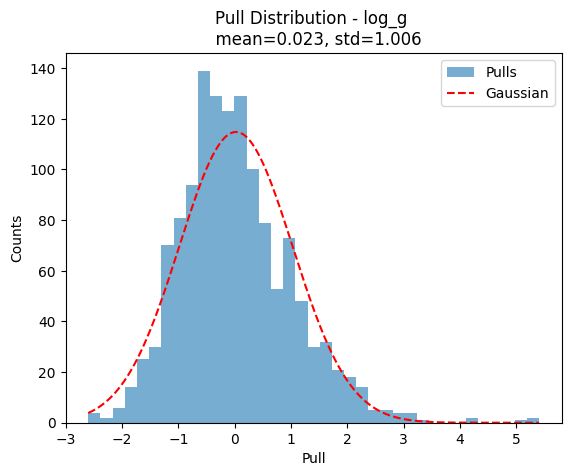

Fe/H: Mean=-0.017, Std=0.990


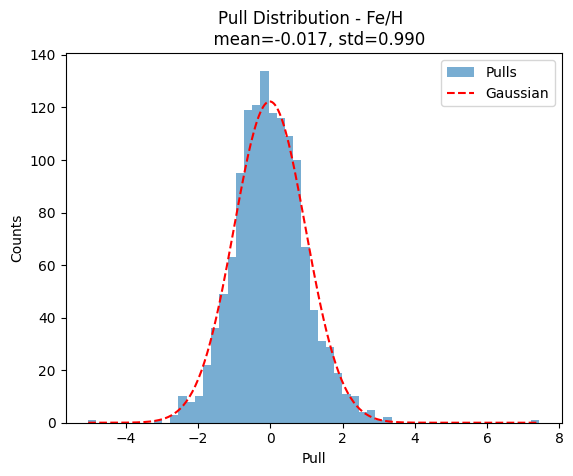

In [21]:
labels_names = ["T_eff", "log_g", "Fe/H"]

pulls = (means - y_true) / stds

for i in range(3):
    # Compute mean and std of the pulls
    mean_pull = np.mean(pulls[:, i])
    std_pull = np.std(pulls[:, i])

    print(f"{labels_names[i]}: Mean={mean_pull:.3f}, Std={std_pull:.3f}")

    plt.figure()

    counts, bins, _ = plt.hist(
        pulls[:, i],
        bins="auto",
        alpha=0.6,
        label="Pulls"
    )

    x = np.linspace(bins[0], bins[-1], 300)

    # Define Gaussian using mean and std
    gaussian = (
        (1 / (std_pull * np.sqrt(2 * np.pi))) *
        np.exp(-0.5 * ((x - mean_pull) / std_pull)**2)
    )
    bin_width = bins[1] - bins[0]
    gaussian_scaled = gaussian * len(pulls[:, i]) * bin_width

    plt.plot(x,gaussian_scaled,'r--',label=f'Gaussian')

    plt.xlabel("Pull")
    plt.ylabel("Counts")
    plt.title(f"Pull Distribution - {labels_names[i]} \n  mean={mean_pull:.3f}, std={std_pull:.3f}")
    plt.legend()
    label = labels_names[i].replace("/", "-")
    plt.savefig(f"plots/pull_dist_{label}", dpi = 300)
    plt.show()


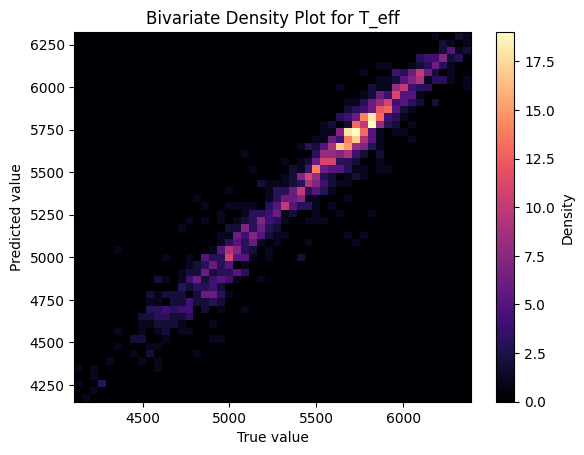

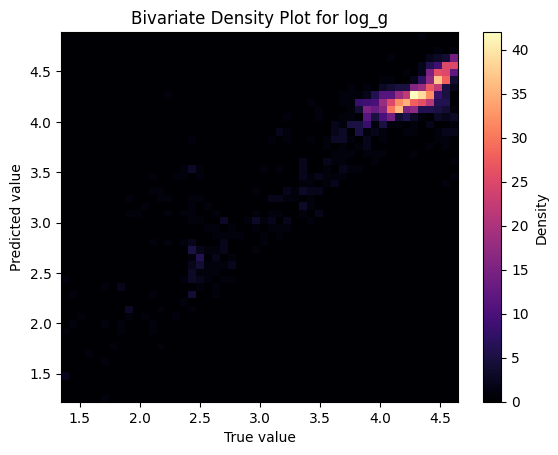

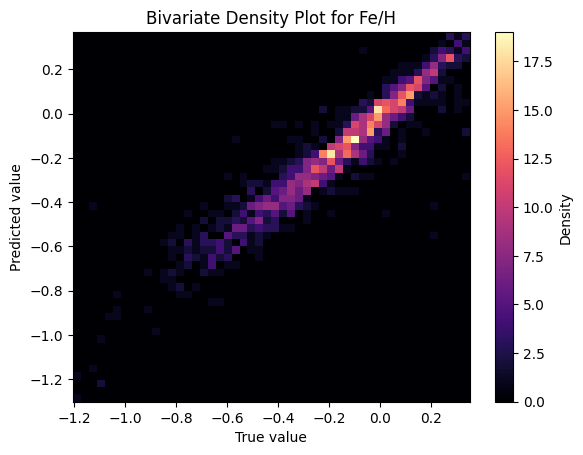

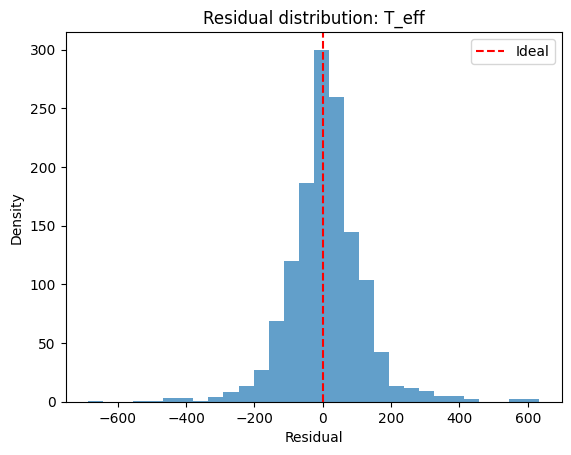

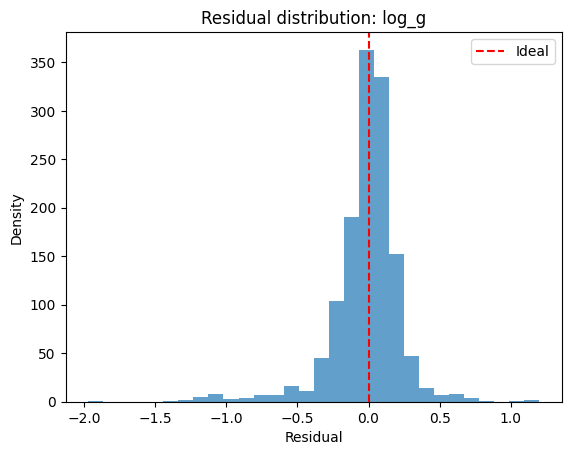

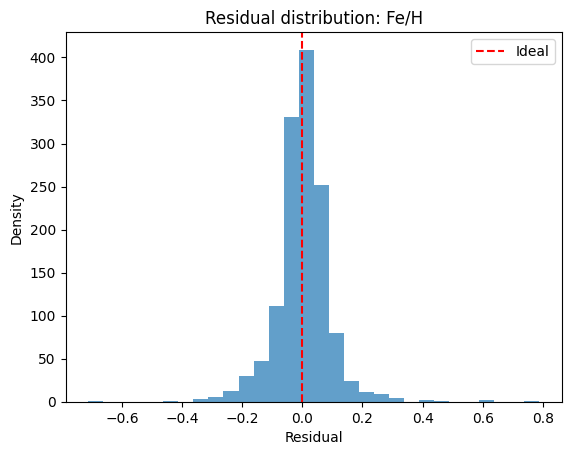

In [19]:
# If labels were normalized, convert back
y_true_real =  denormalize_labels(y_true, mean, std)
means_real =  denormalize_labels(means, mean, std)


# Plots
plot_heatmap(y_true_real, means_real, labels_names)
plot_residuals(y_true_real, means_real, labels_names)